# FusedHelicoidConcentrationDataset Demo

This notebook demonstrates the functionality of the `FusedHelicoidConcentrationDataset` class, which combines HELICOID HSI data with concentration maps from spectral unmixing. The dataset provides both original and wavelength-selected HSI cubes for comprehensive analysis.

## Features Demonstrated:
- Loading fused HSI and concentration data
- Wavelength selection methods (left/right cuts vs. specific wavelengths)
- Comparison of original vs. selected wavelength data
- Visualization of HSI cubes, concentration maps, and spectral signatures
- Real dataset exploration and analysis

In [1]:
import sys
sys.path.append('..')

# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from src.dataset import FusedHelicoidConcentrationDataset
from src.constants import HELICOID_DATA_DIR
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"HELICOID_DATA_DIR from constants: {HELICOID_DATA_DIR}")

Loaded 61 patient IDs from metadata CSV
Libraries imported successfully!
HELICOID_DATA_DIR from constants: /home/ezhovi/npj_database


## Dataset Configuration

Let's set up the paths and wavelength selection for our dataset. You'll need to update the paths to match your data directories.

In [2]:
# Define example selected wavelengths (as mentioned in the requirements)
selected_wavelengths = np.array([
    537.994, 548.18, 555.456, 566.369, 576.555, 586.741, 
    596.927, 606.386, 618.755, 673.323, 724.253, 726.436, 
    739.532, 748.991, 749.718
])

print(f"Selected wavelengths: {selected_wavelengths}")
print(f"Number of selected bands: {len(selected_wavelengths)}")
print(f"Wavelength range: {selected_wavelengths.min():.1f} - {selected_wavelengths.max():.1f} nm")

# Configure dataset paths
# Update these paths to match your actual data directories
helicoid_data_dir = HELICOID_DATA_DIR  # From constants
reduced_wl_dir = "../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced"  # Directory with reduced wavelength concentration maps
gt_dir = "../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750"  # Directory with ground truth concentration maps

print(f"\nDataset Configuration:")
print(f"HELICOID data directory: {helicoid_data_dir}")
print(f"Reduced wavelength concentration directory: {reduced_wl_dir}")
print(f"Ground truth concentration directory: {gt_dir}")

Selected wavelengths: [537.994 548.18  555.456 566.369 576.555 586.741 596.927 606.386 618.755
 673.323 724.253 726.436 739.532 748.991 749.718]
Number of selected bands: 15
Wavelength range: 538.0 - 749.7 nm

Dataset Configuration:
HELICOID data directory: /home/ezhovi/npj_database
Reduced wavelength concentration directory: ../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced
Ground truth concentration directory: ../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750


## Initialize Dataset

We'll create the fused dataset with our selected wavelengths and explore its properties.

In [20]:
dataset = FusedHelicoidConcentrationDataset(
    helicoid_data_dir=helicoid_data_dir,
    reduced_wl_dir=reduced_wl_dir,
    gt_dir=gt_dir,
    selected_wavelengths=selected_wavelengths,
    center_crop_size=224,  # Crop to 224x224 for memory efficiency
    normalize_image=True,
    channels_first=False
)

print("Dataset initialized successfully!")
print(f"Dataset length: {len(dataset)}")


2025-09-18 21:47:38.531 | DEBUG    | src.dataset.helicoid_dataset:_find_patient_samples:206 - Found 70 valid HELICOID patient samples
2025-09-18 21:47:38.538 | INFO     | src.dataset.fused_helicoid_concentration_dataset:_find_common_samples:257 - Found 70 common samples between datasets
2025-09-18 21:47:38.539 | INFO     | src.dataset.fused_helicoid_concentration_dataset:_get_wavelength_indices:294 - Selected 15 wavelength bands from 302 available
2025-09-18 21:47:38.540 | INFO     | src.dataset.fused_helicoid_concentration_dataset:__init__:174 - Initialized FusedHelicoidConcentrationDataset with 70 samples


Initialized wavelengths: 302 bands in range [530, 750)
Found 70 common samples between directories
Dataset initialized successfully!
Dataset length: 70


## Dataset Information

Let's explore the structure and properties of our fused dataset.

In [7]:
summary = dataset.get_summary()
wavelength_info = dataset.get_wavelength_info()

print("Dataset Summary:")
print("=" * 40)
print(f"Total samples: {summary['total_samples']}")
print(f"Number of patients: {summary['num_patients']}")
print(f"Patient IDs: {summary['patient_ids']}")
print(f"Samples per patient: {summary['patient_fov_counts']}")
print()
print("Wavelength Information:")
print(f"Selection method: {wavelength_info['wavelength_selection_method']}")
print(f"Number of selected bands: {wavelength_info['num_selected_bands']}")
print(f"Wavelength range: {wavelength_info['wavelength_range']}")
print()
print("Configuration:")
print(f"Center crop size: {summary['center_crop_size']}")
print(f"Normalize image: {summary['normalize_image']}")
print(f"Reduced wavelength directory: {summary['reduced_wl_dir']}")
print(f"Ground truth directory: {summary['gt_dir']}")


Dataset Summary:
Total samples: 70
Number of patients: 40
Patient IDs: ['004', '005', '007', '008', '010', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '025', '026', '027', '028', '029', '030', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '050', '051', '053', '054', '055', '056', '057', '058']
Samples per patient: {'004': 1, '005': 1, '007': 1, '008': 2, '010': 1, '012': 2, '013': 1, '014': 1, '015': 1, '016': 5, '017': 1, '018': 2, '019': 1, '020': 1, '021': 3, '022': 3, '025': 1, '026': 1, '027': 1, '028': 3, '029': 2, '030': 1, '034': 3, '035': 2, '036': 2, '037': 4, '038': 1, '039': 2, '040': 2, '041': 2, '042': 3, '043': 3, '050': 1, '051': 1, '053': 1, '054': 1, '055': 2, '056': 2, '057': 1, '058': 1}

Wavelength Information:
Selection method: selected_wavelengths
Number of selected bands: 15
Wavelength range: 537.994 - 749.718 nm

Configuration:
Center crop size: 224
Normalize image: True
Reduced wavelength directory: ../r

## Examine Sample Structure

Let's look at the structure of a real sample from the fused dataset.

In [22]:
# Get the first sample
sample = dataset.get_sample_by_id("008-01")

print("Sample Structure:")
print("=" * 30)
print(f"Sample ID: {sample['id']}")
print(f"Patient ID: {sample['patient_id']}")
print(f"FOV: {sample['fov']}")
print()
print("HSI Data:")
print(f"  Original HSI cube shape: {sample['hsi_cube_original'].shape} (C, H, W)")
print(f"  Selected HSI cube shape: {sample['hsi_cube'].shape} (C, H, W)")
print(f"  Selected wavelengths: {len(sample['wavelengths'])} bands")
print()
print("Other Data:")
print(f"  Ground truth map shape: {sample['gt_map'].shape}")
print(f"  Concentration data structure:")
print(f"    Reduced wavelength:")
print(
    f"      - Coefficients shape: {sample.concentration_data['reduced_wl']['coef_list'].shape}"
)
print(
    f"      - Scattering parameters shape: {sample.concentration_data['reduced_wl']['scatter_params'].shape}"
)
print(f"    Ground truth:")
print(f"      - Coefficients shape: {sample.concentration_data['gt']['coef_list'].shape}")
print(
    f"      - Scattering parameters shape: {sample.concentration_data['gt']['scatter_params'].shape}"
)

# Show wavelength comparison
print(f"\nWavelength Comparison:")
print(
    f"  Selected range: {sample['wavelengths'].min():.1f} - {sample['wavelengths'].max():.1f} nm"
)

2025-09-18 21:48:24.332 | DEBUG    | src.dataset.helicoid_dataset:__getitem__:277 - {'id': '008-01', 'patient_id': '008', 'fov': '01', 'patient_dir': PosixPath('/home/ezhovi/npj_database/008-01'), 'raw_path': PosixPath('/home/ezhovi/npj_database/008-01/raw.hdr'), 'gt_path': PosixPath('/home/ezhovi/npj_database/008-01/gtMap.hdr'), 'rgb_path': PosixPath('/home/ezhovi/npj_database/008-01/image.jpg'), 'white_ref_path': PosixPath('/home/ezhovi/npj_database/008-01/whiteReference.hdr'), 'dark_ref_path': PosixPath('/home/ezhovi/npj_database/008-01/darkReference.hdr')}
2025-09-18 21:48:28.390 | DEBUG    | src.dataset.concentrations_dataset:__getitem__:698 - {'id': '008-01', 'patient_id': '008', 'fov': '01', 'reduced_wl_path': PosixPath('../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced/008-01'), 'gt_path': PosixPath('../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750/008-01')}


Sample Structure:
Sample ID: 008-01
Patient ID: 008
FOV: 01

HSI Data:
  Original HSI cube shape: (302, 224, 224) (C, H, W)
  Selected HSI cube shape: (15, 224, 224) (C, H, W)
  Selected wavelengths: 15 bands

Other Data:
  Ground truth map shape: (224, 224)
  Concentration data structure:
    Reduced wavelength:
      - Coefficients shape: (224, 224, 10)
      - Scattering parameters shape: (224, 224, 2)
    Ground truth:
      - Coefficients shape: (224, 224, 10)
      - Scattering parameters shape: (224, 224, 2)

Wavelength Comparison:
  Selected range: 538.0 - 749.7 nm


## Visualize HSI Data

Let's create visualizations of the HSI cubes and compare original vs. selected wavelengths.

2025-09-18 21:49:38.802 | DEBUG    | src.dataset.helicoid_dataset:__getitem__:277 - {'id': '008-01', 'patient_id': '008', 'fov': '01', 'patient_dir': PosixPath('/home/ezhovi/npj_database/008-01'), 'raw_path': PosixPath('/home/ezhovi/npj_database/008-01/raw.hdr'), 'gt_path': PosixPath('/home/ezhovi/npj_database/008-01/gtMap.hdr'), 'rgb_path': PosixPath('/home/ezhovi/npj_database/008-01/image.jpg'), 'white_ref_path': PosixPath('/home/ezhovi/npj_database/008-01/whiteReference.hdr'), 'dark_ref_path': PosixPath('/home/ezhovi/npj_database/008-01/darkReference.hdr')}
2025-09-18 21:49:42.849 | DEBUG    | src.dataset.concentrations_dataset:__getitem__:698 - {'id': '008-01', 'patient_id': '008', 'fov': '01', 'reduced_wl_path': PosixPath('../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced/008-01'), 'gt_path': PosixPath('../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750/008-01')}


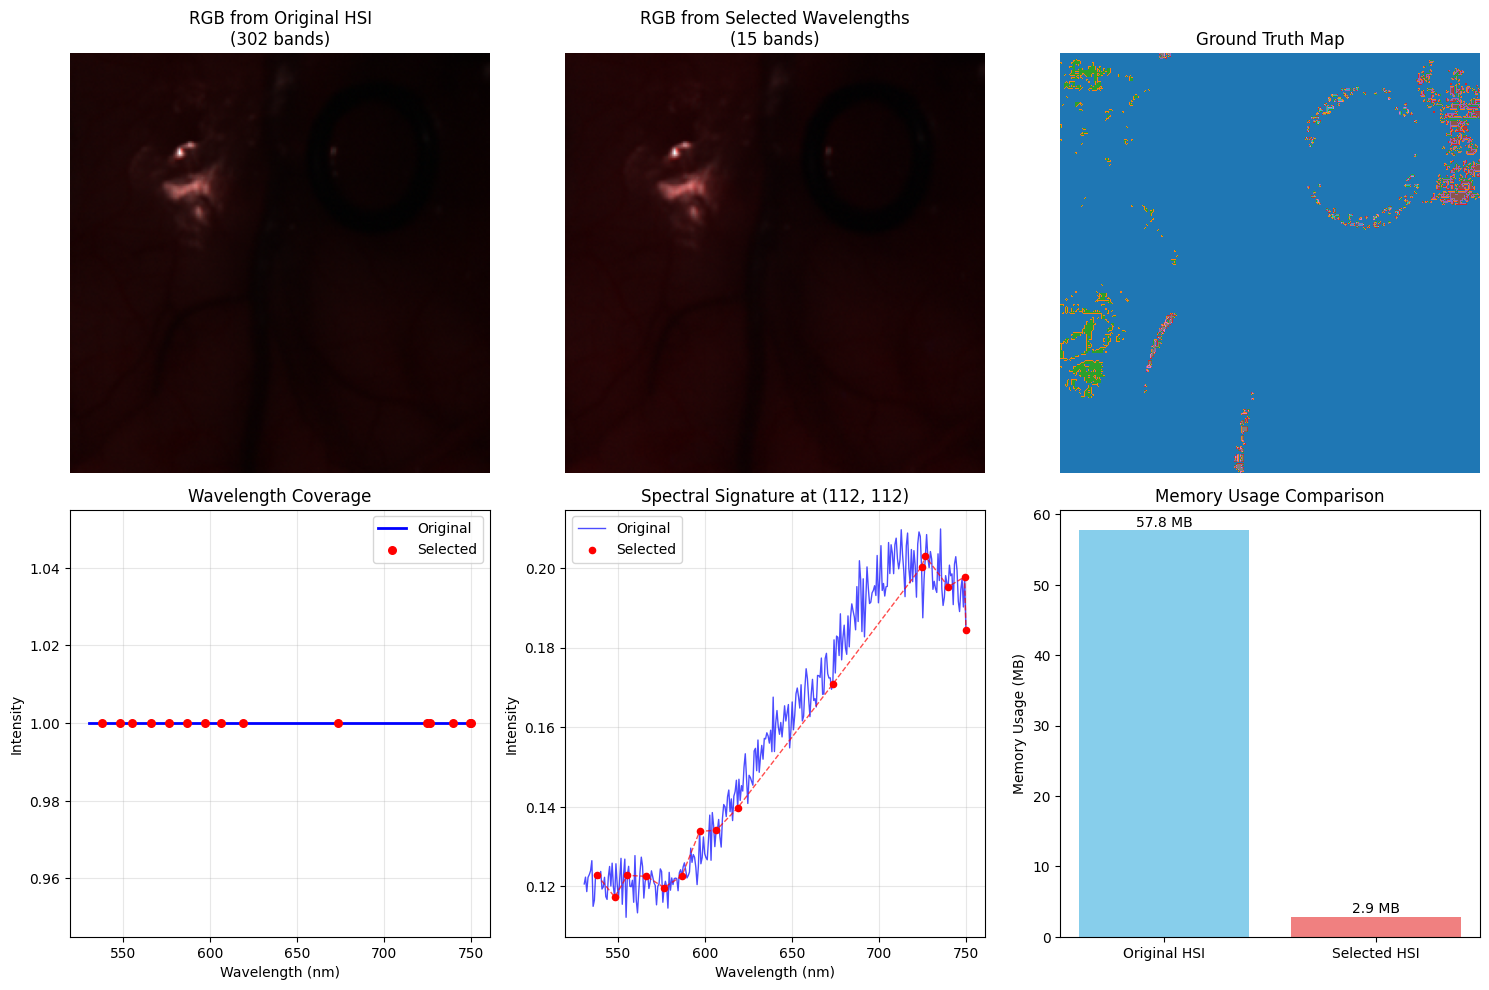

RGB bands used: R=650.0nm, G=550.4nm, B=530.7nm


In [24]:
from src.constants import HELICOID_WAVELENGTHS

def create_rgb_from_hsi(hsi_cube, wavelengths, rgb_bands=[650, 550, 450]):
    """Create an RGB image from HSI cube by selecting wavelength bands closest to RGB."""
    height, width = hsi_cube.shape[1], hsi_cube.shape[2]
    rgb_image = np.zeros((height, width, 3))
    
    for i, target_wl in enumerate(rgb_bands):
        # Find closest wavelength
        closest_idx = np.argmin(np.abs(wavelengths - target_wl))
        band_data = hsi_cube[closest_idx, :, :]
        
        # Normalize to 0-1 range
        band_normalized = (band_data - band_data.min()) / (band_data.max() - band_data.min())
        rgb_image[:, :, i] = band_normalized
    
    return rgb_image, [wavelengths[np.argmin(np.abs(wavelengths - wl))] for wl in rgb_bands]

# Create RGB representations
sample = dataset.get_sample_by_id("008-01")
wavelengths_original = dataset.helicoid_dataset._cut_wavelengths
rgb_original, used_wl_orig = create_rgb_from_hsi(sample['hsi_cube_original'], wavelengths_original)
rgb_selected, used_wl_sel = create_rgb_from_hsi(sample['hsi_cube'], sample['wavelengths'])

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: RGB images
axes[0, 0].imshow(rgb_original)
axes[0, 0].set_title(f'RGB from Original HSI\n({len(wavelengths_original)} bands)')
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_selected)
axes[0, 1].set_title(f'RGB from Selected Wavelengths\n({len(sample["wavelengths"])} bands)')
axes[0, 1].axis('off')

axes[0, 2].imshow(sample['gt_map'], cmap='tab10')
axes[0, 2].set_title('Ground Truth Map')
axes[0, 2].axis('off')

# Bottom row: Spectral information
axes[1, 0].plot(wavelengths_original, np.ones_like(wavelengths_original), 'b-', linewidth=2, label='Original')
axes[1, 0].scatter(sample['wavelengths'], np.ones_like(sample['wavelengths']), c='red', s=30, zorder=5, label='Selected')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('Intensity')
axes[1, 0].set_title('Wavelength Coverage')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Show single pixel spectrum comparison
pixel_row, pixel_col = sample['hsi_cube'].shape[1]//2, sample['hsi_cube'].shape[2]//2
spectrum_orig = sample['hsi_cube_original'][:, pixel_row, pixel_col]
spectrum_sel = sample['hsi_cube'][:, pixel_row, pixel_col]

axes[1, 1].plot(wavelengths_original, spectrum_orig, 'b-', linewidth=1, alpha=0.7, label='Original')
axes[1, 1].scatter(sample['wavelengths'], spectrum_sel, c='red', s=20, zorder=5, label='Selected')
axes[1, 1].plot(sample['wavelengths'], spectrum_sel, 'r--', linewidth=1, alpha=0.7)
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Intensity')
axes[1, 1].set_title(f'Spectral Signature at ({pixel_row}, {pixel_col})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Memory usage comparison
original_size_mb = sample['hsi_cube_original'].nbytes / (1024 * 1024)
selected_size_mb = sample['hsi_cube'].nbytes / (1024 * 1024)

categories = ['Original HSI', 'Selected HSI']
sizes = [original_size_mb, selected_size_mb]
colors = ['skyblue', 'lightcoral']

bars = axes[1, 2].bar(categories, sizes, color=colors)
axes[1, 2].set_ylabel('Memory Usage (MB)')
axes[1, 2].set_title('Memory Usage Comparison')

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{size:.1f} MB', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"RGB bands used: R={used_wl_orig[0]:.1f}nm, G={used_wl_orig[1]:.1f}nm, B={used_wl_orig[2]:.1f}nm")



## Concentration Data Visualization

Let's visualize the concentration maps for different molecules, comparing reduced wavelength and ground truth results.

2025-09-18 21:47:49.498 | DEBUG    | src.dataset.helicoid_dataset:__getitem__:277 - {'id': '008-01', 'patient_id': '008', 'fov': '01', 'patient_dir': PosixPath('/home/ezhovi/npj_database/008-01'), 'raw_path': PosixPath('/home/ezhovi/npj_database/008-01/raw.hdr'), 'gt_path': PosixPath('/home/ezhovi/npj_database/008-01/gtMap.hdr'), 'rgb_path': PosixPath('/home/ezhovi/npj_database/008-01/image.jpg'), 'white_ref_path': PosixPath('/home/ezhovi/npj_database/008-01/whiteReference.hdr'), 'dark_ref_path': PosixPath('/home/ezhovi/npj_database/008-01/darkReference.hdr')}
2025-09-18 21:47:53.540 | DEBUG    | src.dataset.concentrations_dataset:__getitem__:698 - {'id': '008-01', 'patient_id': '008', 'fov': '01', 'reduced_wl_path': PosixPath('../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced/008-01'), 'gt_path': PosixPath('../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750/008-01')}


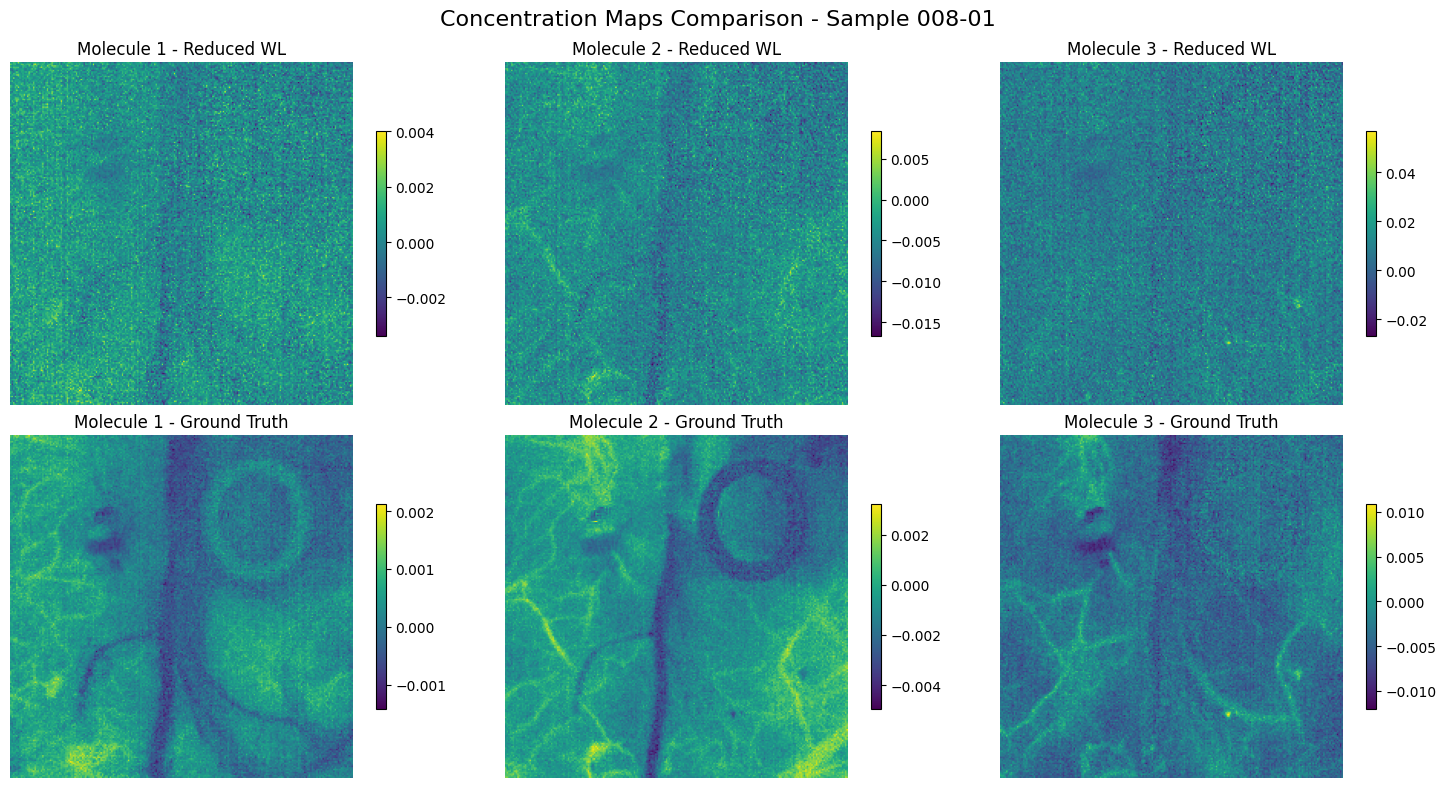

Concentration Data Comparison:
Sample ID: 008-01
Number of molecules: 10
Reduced wavelength - Concentration map shape: (224, 224, 10)
Ground truth - Concentration map shape: (224, 224, 10)
Reduced wavelength - Scattering parameters shape: (224, 224, 2)
Ground truth - Scattering parameters shape: (224, 224, 2)

Molecule 1:
  Reduced WL: mean=0.0004, std=0.0009
  Ground Truth: mean=0.0002, std=0.0005
  Correlation: 0.4629

Molecule 2:
  Reduced WL: mean=-0.0047, std=0.0028
  Ground Truth: mean=-0.0008, std=0.0011
  Correlation: 0.4233

Molecule 3:
  Reduced WL: mean=0.0084, std=0.0086
  Ground Truth: mean=-0.0033, std=0.0023
  Correlation: 0.2359

Molecule 4:
  Reduced WL: mean=-0.0011, std=0.0016
  Ground Truth: mean=0.0008, std=0.0005
  Correlation: 0.2385

Molecule 5:
  Reduced WL: mean=-0.0244, std=0.0282
  Ground Truth: mean=0.0112, std=0.0147
  Correlation: 0.5872

Molecule 6:
  Reduced WL: mean=0.0009, std=0.0011
  Ground Truth: mean=0.0001, std=0.0005
  Correlation: 0.3860

Molec

In [21]:
sample = dataset.get_sample_by_id("008-01")
concentration_data = sample['concentration_data']

# Get both reduced wavelength and ground truth data
reduced_wl_data = concentration_data['reduced_wl']
gt_data = concentration_data['gt']

coef_list_reduced = reduced_wl_data['coef_list']  # Shape: (H, W, num_molecules)
scatter_params_reduced = reduced_wl_data['scatter_params']  # Shape: (H, W, 2)

coef_list_gt = gt_data['coef_list']  # Shape: (H, W, num_molecules)
scatter_params_gt = gt_data['scatter_params']  # Shape: (H, W, 2)

num_molecules = coef_list_reduced.shape[2]

# Create molecule names
molecule_names = [f'Molecule {i+1}' for i in range(num_molecules)]

# Create comparison visualization - reduced vs ground truth
n_molecules_to_show = min(3, num_molecules)  # Show first 3 molecules

fig, axes = plt.subplots(2, n_molecules_to_show, figsize=(5*n_molecules_to_show, 8))
if n_molecules_to_show == 1:
    axes = axes.reshape(2, 1)

# Top row: Reduced wavelength results
for i in range(n_molecules_to_show):
    im = axes[0, i].imshow(coef_list_reduced[:, :, i], cmap='viridis')
    axes[0, i].set_title(f'{molecule_names[i]} - Reduced WL')
    axes[0, i].axis('off')
    plt.colorbar(im, ax=axes[0, i], shrink=0.6)

# Bottom row: Ground truth results
for i in range(n_molecules_to_show):
    im = axes[1, i].imshow(coef_list_gt[:, :, i], cmap='viridis')
    axes[1, i].set_title(f'{molecule_names[i]} - Ground Truth')
    axes[1, i].axis('off')
    plt.colorbar(im, ax=axes[1, i], shrink=0.6)

plt.suptitle(f'Concentration Maps Comparison - Sample {sample["id"]}', fontsize=16)
plt.tight_layout()
plt.show()

# Print comparison statistics
print("Concentration Data Comparison:")
print("=" * 50)
print(f"Sample ID: {sample['id']}")
print(f"Number of molecules: {num_molecules}")
print(f"Reduced wavelength - Concentration map shape: {coef_list_reduced.shape}")
print(f"Ground truth - Concentration map shape: {coef_list_gt.shape}")
print(f"Reduced wavelength - Scattering parameters shape: {scatter_params_reduced.shape}")
print(f"Ground truth - Scattering parameters shape: {scatter_params_gt.shape}")
print()

# Statistical comparison between reduced and ground truth
for i in range(num_molecules):
    reduced_data = coef_list_reduced[:, :, i]
    gt_data_mol = coef_list_gt[:, :, i]
    
    correlation = np.corrcoef(reduced_data.flatten(), gt_data_mol.flatten())[0, 1]
    
    print(f"{molecule_names[i]}:")
    print(f"  Reduced WL: mean={reduced_data.mean():.4f}, std={reduced_data.std():.4f}")
    print(f"  Ground Truth: mean={gt_data_mol.mean():.4f}, std={gt_data_mol.std():.4f}")
    print(f"  Correlation: {correlation:.4f}")
    print()

## Dataset Exploration

Let's explore multiple samples and patients to understand the dataset diversity.

Dataset Exploration:
Available patients: ['004', '005', '007', '008', '010', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '025', '026', '027', '028', '029', '030', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '050', '051', '053', '054', '055', '056', '057', '058']

Patient 004:
  Available FOVs: ['02']
  Sample 004-02:
    HSI shape: (15, 224, 224)
    Reduced WL concentration shape: (224, 224, 10)
    GT concentration shape: (224, 224, 10)
    HSI statistics: mean=0.6732, std=0.4975

Patient 005:
  Available FOVs: ['01']
  Sample 005-01:
    HSI shape: (15, 224, 224)
    Reduced WL concentration shape: (224, 224, 10)
    GT concentration shape: (224, 224, 10)
    HSI statistics: mean=0.2769, std=0.2136

Patient 007:
  Available FOVs: ['01']
  Sample 007-01:
    HSI shape: (15, 224, 224)
    Reduced WL concentration shape: (224, 224, 10)
    GT concentration shape: (224, 224, 10)
    HSI statistics: mean=0.5136, std=0.4223

Compa

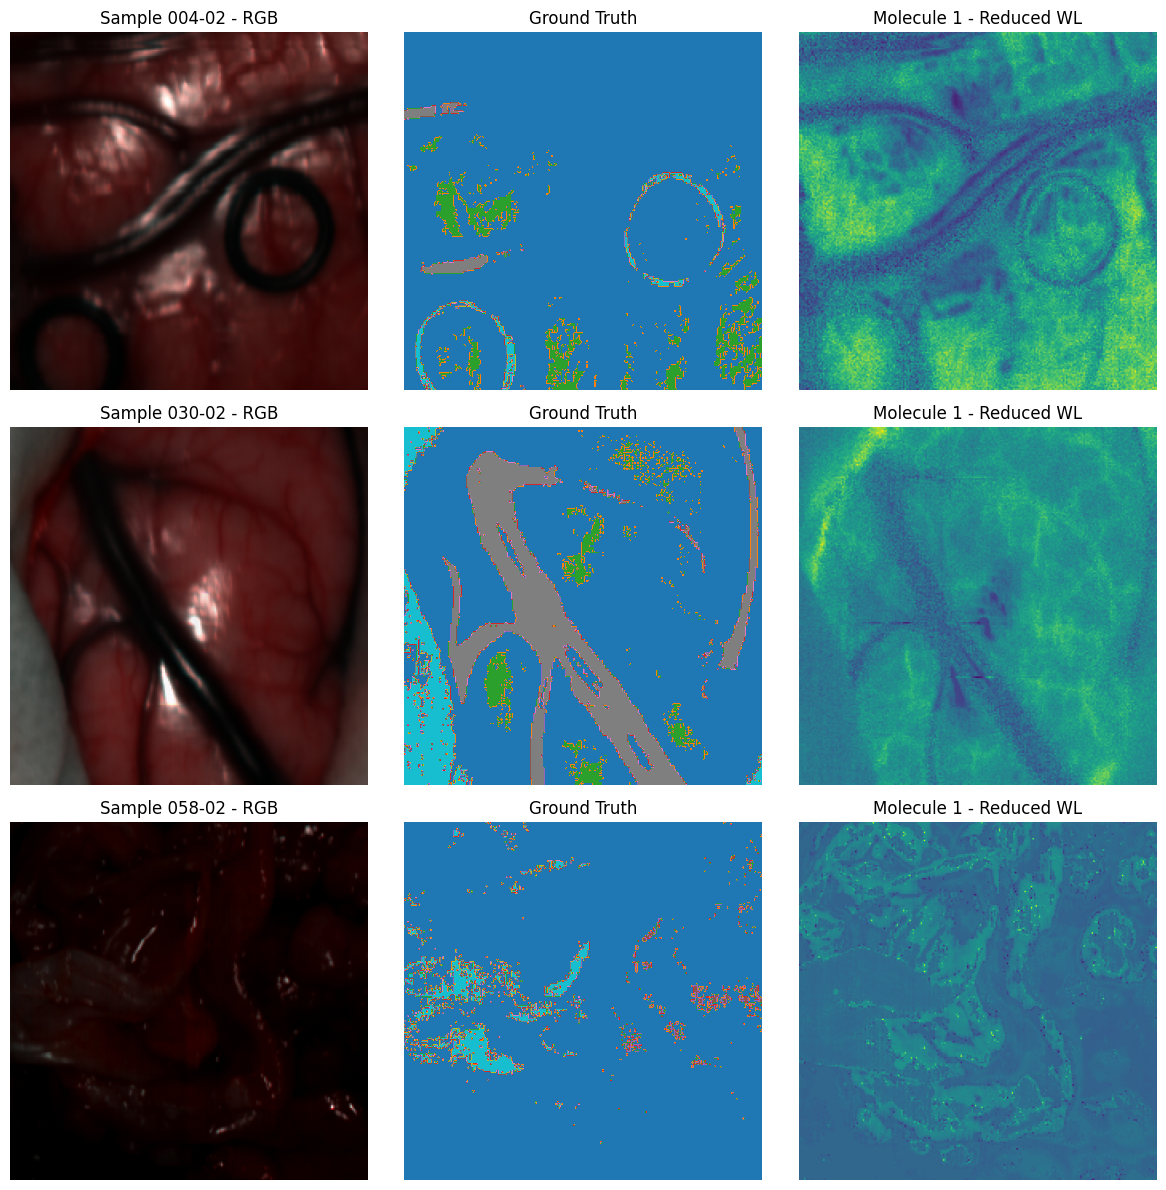

In [8]:
print("Dataset Exploration:")
print("=" * 30)

# Get patient information
patient_ids = dataset.get_patient_ids()
print(f"Available patients: {patient_ids}")

# Explore samples for each patient
for patient_id in patient_ids[:3]:  # Show first 3 patients
    fovs = dataset.get_fovs_for_patient(patient_id)
    print(f"\nPatient {patient_id}:")
    print(f"  Available FOVs: {fovs}")
    
    # Get first sample for this patient
    if fovs:
        patient_sample = dataset.get_sample_by_patient_and_fov(patient_id, fovs[0])
        if patient_sample:
            print(f"  Sample {patient_sample['id']}:")
            print(f"    HSI shape: {patient_sample['hsi_cube'].shape}")
            print(f"    Reduced WL concentration shape: {patient_sample['concentration_data']['reduced_wl']['coef_list'].shape}")
            print(f"    GT concentration shape: {patient_sample['concentration_data']['gt']['coef_list'].shape}")
            
            # Show some basic statistics
            hsi_mean = patient_sample['hsi_cube'].mean()
            hsi_std = patient_sample['hsi_cube'].std()
            print(f"    HSI statistics: mean={hsi_mean:.4f}, std={hsi_std:.4f}")

# Sample comparison across patients
if len(dataset) >= 3:
    print(f"\nComparing Multiple Samples:")
    print("=" * 30)
    
    sample_indices = [0, len(dataset)//2, len(dataset)-1] if len(dataset) > 2 else list(range(len(dataset)))
    
    fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4*len(sample_indices)))
    if len(sample_indices) == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(sample_indices):
        sample = dataset[idx]
        
        # Create RGB from selected wavelengths
        rgb_image, _ = create_rgb_from_hsi(sample['hsi_cube'], sample['wavelengths'])
        
        # Plot RGB
        axes[i, 0].imshow(rgb_image)
        axes[i, 0].set_title(f'Sample {sample["id"]} - RGB')
        axes[i, 0].axis('off')
        
        # Plot ground truth
        axes[i, 1].imshow(sample['gt_map'], cmap='tab10')
        axes[i, 1].set_title(f'Ground Truth')
        axes[i, 1].axis('off')
        
        # Plot first concentration map (reduced wavelength version)
        axes[i, 2].imshow(sample['concentration_data']['reduced_wl']['coef_list'][:, :, 0], cmap='viridis')
        axes[i, 2].set_title(f'Molecule 1 - Reduced WL')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

## Wavelength Selection Analysis

Let's analyze the effect of our wavelength selection on the spectral information.

Spectral Coverage Analysis:
Original wavelength range: 530.7 - 749.7 nm
Selected wavelength range: 538.0 - 749.7 nm
Original spectral resolution: 0.73 nm
Average gap in selection: 15.12 nm
Largest gap in selection: 54.57 nm


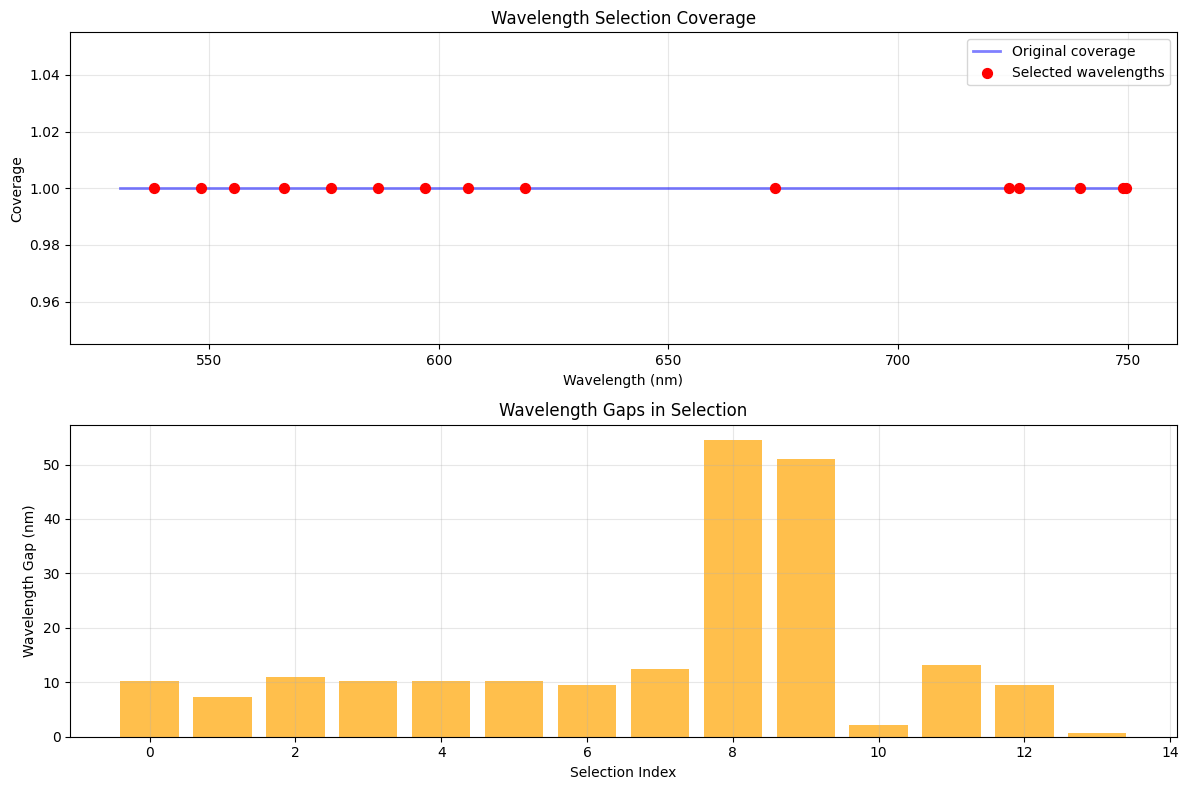


Spectral Information Preservation:
Average spectral correlation: 0.998 ± 0.003
Correlation range: 0.989 - 0.999
Information variance (original): 0.197093
Information variance (selected): 0.190897


In [9]:
sample = dataset[0]

# Analyze spectral coverage
def analyze_spectral_coverage(original_wl, selected_wl):
    """Analyze spectral coverage and gaps."""
    
    print("Spectral Coverage Analysis:")
    print("=" * 40)
    print(f"Original wavelength range: {original_wl.min():.1f} - {original_wl.max():.1f} nm")
    print(f"Selected wavelength range: {selected_wl.min():.1f} - {selected_wl.max():.1f} nm")
    print(f"Original spectral resolution: {np.mean(np.diff(original_wl)):.2f} nm")
    print(f"Average gap in selection: {np.mean(np.diff(selected_wl)):.2f} nm")
    print(f"Largest gap in selection: {np.max(np.diff(selected_wl)):.2f} nm")
    
    # Plot spectral coverage
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Coverage plot
    ax1.plot(original_wl, np.ones_like(original_wl), 'b-', linewidth=2, alpha=0.5, label='Original coverage')
    ax1.scatter(selected_wl, np.ones_like(selected_wl), c='red', s=50, zorder=5, label='Selected wavelengths')
    ax1.set_xlabel('Wavelength (nm)')
    ax1.set_ylabel('Coverage')
    ax1.set_title('Wavelength Selection Coverage')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gap analysis
    gaps = np.diff(selected_wl)
    ax2.bar(range(len(gaps)), gaps, alpha=0.7, color='orange')
    ax2.set_xlabel('Selection Index')
    ax2.set_ylabel('Wavelength Gap (nm)')
    ax2.set_title('Wavelength Gaps in Selection')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return gaps

gaps = analyze_spectral_coverage(sample['wavelengths_original'], sample['wavelengths'])

# Spectral correlation analysis
print(f"\nSpectral Information Preservation:")
print("=" * 40)

# Sample a few random pixels for correlation analysis
height, width = sample['hsi_cube'].shape[1], sample['hsi_cube'].shape[2]
n_pixels = 10
correlations = []

np.random.seed(42)
for _ in range(n_pixels):
    row = np.random.randint(0, height)
    col = np.random.randint(0, width)
    
    original_spectrum = sample['hsi_cube_original'][:, row, col]
    selected_spectrum = sample['hsi_cube'][:, row, col]
    
    # Interpolate selected spectrum to original wavelength grid for comparison
    interpolated = np.interp(sample['wavelengths_original'], sample['wavelengths'], selected_spectrum)
    
    correlation = np.corrcoef(original_spectrum, interpolated)[0, 1]
    correlations.append(correlation)

print(f"Average spectral correlation: {np.mean(correlations):.3f} ± {np.std(correlations):.3f}")
print(f"Correlation range: {np.min(correlations):.3f} - {np.max(correlations):.3f}")

# Information content analysis
original_variance = np.var(sample['hsi_cube_original'], axis=(1, 2))
selected_variance = np.var(sample['hsi_cube'], axis=(1, 2))

print(f"Information variance (original): {np.mean(original_variance):.6f}")
print(f"Information variance (selected): {np.mean(selected_variance):.6f}")


## Visualize RGB Representation

Create RGB visualizations from both the original and selected wavelength HSI cubes.

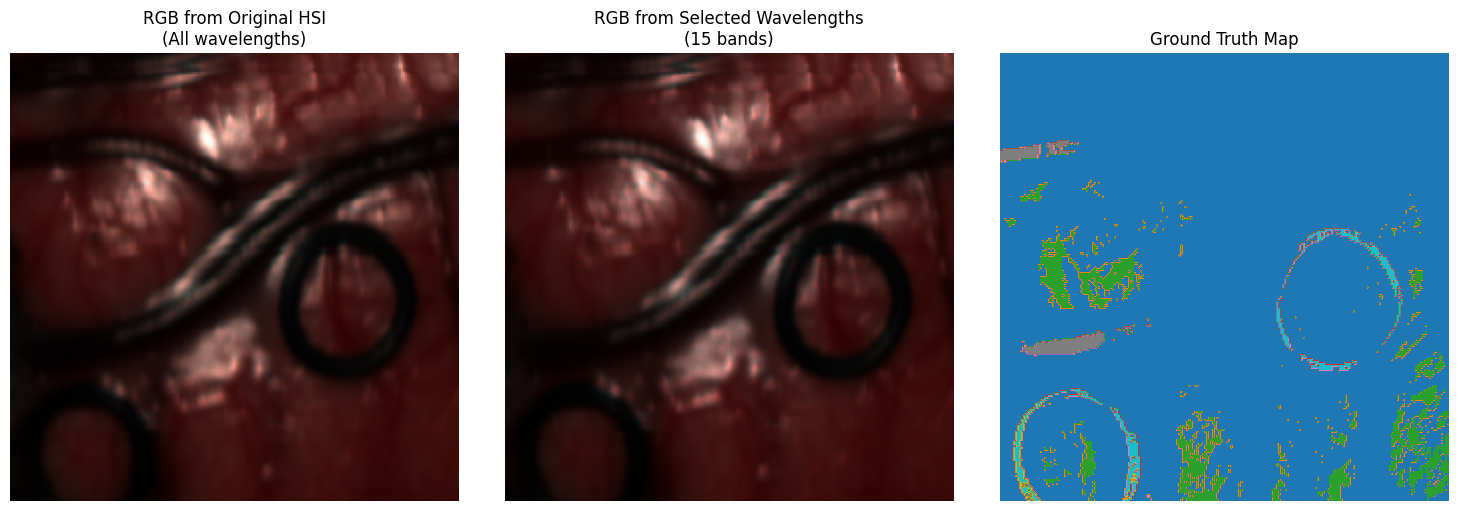

RGB bands used: R=650nm, G=550nm, B=450nm
Original HSI: 302 bands
Selected HSI: 15 bands


In [10]:
def create_rgb_from_hsi(hsi_cube, wavelengths, rgb_bands=[650, 550, 450]):
    """
    Create an RGB image from HSI cube by selecting wavelength bands closest to RGB.
    
    Parameters:
    -----------
    hsi_cube : np.ndarray
        HSI cube with shape (C, H, W)
    wavelengths : np.ndarray
        Wavelengths corresponding to each band
    rgb_bands : list
        Target wavelengths for R, G, B channels
        
    Returns:
    --------
    np.ndarray : RGB image with shape (H, W, 3)
    """
    height, width = hsi_cube.shape[1], hsi_cube.shape[2]
    rgb_image = np.zeros((height, width, 3))
    
    for i, target_wl in enumerate(rgb_bands):
        # Find closest wavelength
        closest_idx = np.argmin(np.abs(wavelengths - target_wl))
        band_data = hsi_cube[closest_idx, :, :]
        
        # Normalize to 0-1 range
        band_normalized = (band_data - band_data.min()) / (band_data.max() - band_data.min())
        rgb_image[:, :, i] = band_normalized
    
    return rgb_image

# Create RGB representations
rgb_original = create_rgb_from_hsi(sample['hsi_cube_original'], sample['wavelengths_original'])
rgb_selected = create_rgb_from_hsi(sample['hsi_cube'], sample['wavelengths'])

# Visualize RGB representations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb_original)
axes[0].set_title('RGB from Original HSI\n(All wavelengths)')
axes[0].axis('off')

axes[1].imshow(rgb_selected)
axes[1].set_title('RGB from Selected Wavelengths\n(15 bands)')
axes[1].axis('off')

axes[2].imshow(sample['gt_map'], cmap='tab10')
axes[2].set_title('Ground Truth Map')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"RGB bands used: R={650}nm, G={550}nm, B={450}nm")
print(f"Original HSI: {sample['hsi_cube_original'].shape[0]} bands")
print(f"Selected HSI: {sample['hsi_cube'].shape[0]} bands")

## Select Specific Wavelengths

Demonstrate how wavelength selection affects the data and explore different selection strategies.

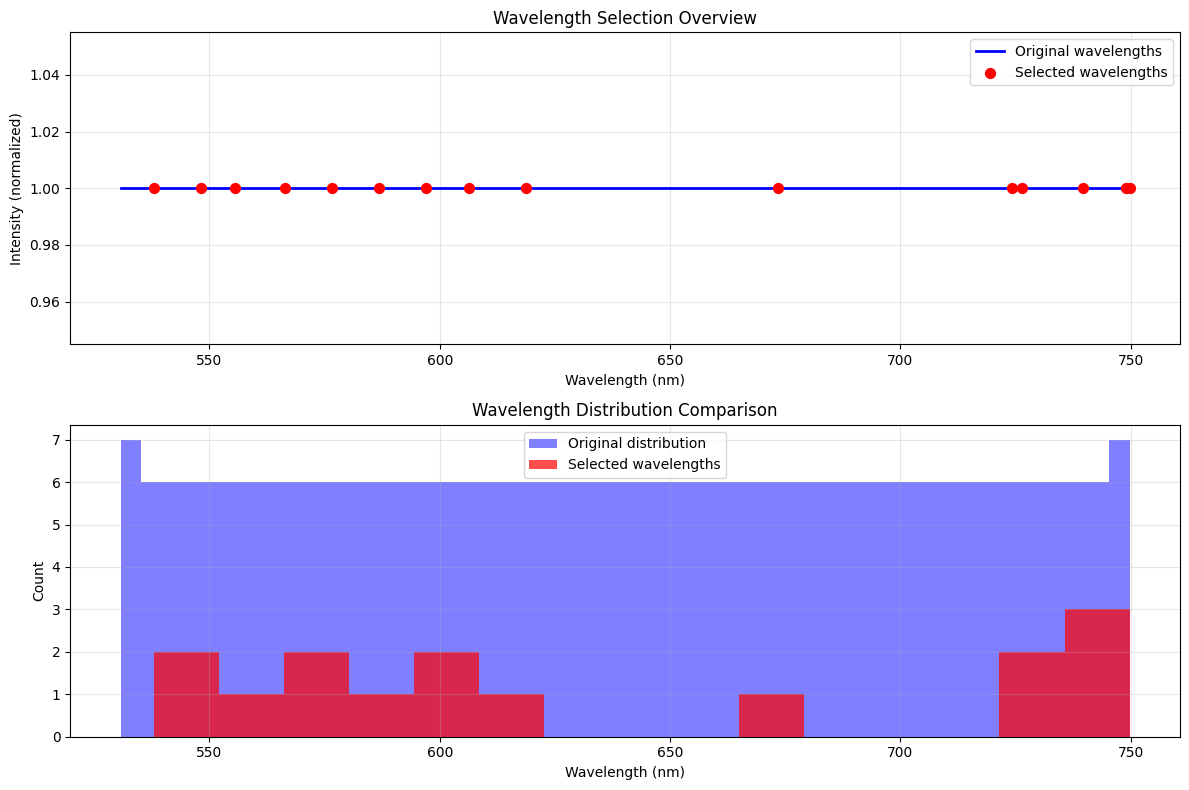

Wavelength Selection Analysis:
Original wavelength range: 530.7 - 749.7 nm
Selected wavelength range: 538.0 - 749.7 nm
Number of original bands: 302
Number of selected bands: 15
Data reduction: 95.0%
Average wavelength gap: 15.1 nm
Wavelength gap range: 0.7 - 54.6 nm


In [11]:
# Analyze wavelength selection
def analyze_wavelength_selection(original_wavelengths, selected_wavelengths):
    """Analyze the wavelength selection and show coverage."""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: All wavelengths with selected ones highlighted
    ax1.plot(original_wavelengths, np.ones_like(original_wavelengths), 'b-', linewidth=2, label='Original wavelengths')
    ax1.scatter(selected_wavelengths, np.ones_like(selected_wavelengths), 
               c='red', s=50, zorder=5, label='Selected wavelengths')
    ax1.set_xlabel('Wavelength (nm)')
    ax1.set_ylabel('Intensity (normalized)')
    ax1.set_title('Wavelength Selection Overview')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Distribution of selected wavelengths
    ax2.hist(original_wavelengths, bins=50, alpha=0.5, label='Original distribution', color='blue')
    ax2.hist(selected_wavelengths, bins=15, alpha=0.7, label='Selected wavelengths', color='red')
    ax2.set_xlabel('Wavelength (nm)')
    ax2.set_ylabel('Count')
    ax2.set_title('Wavelength Distribution Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("Wavelength Selection Analysis:")
    print("=" * 40)
    print(f"Original wavelength range: {original_wavelengths.min():.1f} - {original_wavelengths.max():.1f} nm")
    print(f"Selected wavelength range: {selected_wavelengths.min():.1f} - {selected_wavelengths.max():.1f} nm")
    print(f"Number of original bands: {len(original_wavelengths)}")
    print(f"Number of selected bands: {len(selected_wavelengths)}")
    print(f"Data reduction: {((len(original_wavelengths) - len(selected_wavelengths)) / len(original_wavelengths) * 100):.1f}%")
    
    # Show wavelength gaps
    if len(selected_wavelengths) > 1:
        wavelength_gaps = np.diff(selected_wavelengths)
        print(f"Average wavelength gap: {wavelength_gaps.mean():.1f} nm")
        print(f"Wavelength gap range: {wavelength_gaps.min():.1f} - {wavelength_gaps.max():.1f} nm")

analyze_wavelength_selection(sample['wavelengths_original'], sample['wavelengths'])